# Hydrologic Parameter Preparation for Machine Learning

## Introduction

This notebook outlines the systematic, multi-stage process for cleaning, filtering, and preparing calibrated ModClark hydrologic parameters—specifically the **time of concentration ($T_c$)** and the **storage coefficient ($R$)**. The data originates from thousands of storm events across hundreds of watersheds.

The primary goal is to engineer a high-quality, robust, and reliable feature set to train a machine learning model. This model will ultimately predict $T_c$ and $R$ for ungauged basins, making this preparatory work a critical foundation for the project's success.

---

### Analysis Workflow

The workflow is divided into four main stages, each building upon the last to progressively refine the dataset.

1.  **Initial Performance Assessment:** We begin by evaluating the quality of all initial parameter calibrations using the **Nash-Sutcliffe Efficiency (NSE)**. A logistic regression model is used to systematically analyze the relationship between various storm characteristics and model performance. This diagnostic step helps identify the primary drivers of poor model fits, which could indicate systematic data quality or modeling issues.

2.  **Data Cleaning and Filtering:** A rigorous, multi-step filtering protocol is applied to the event data. This involves:
    * First, a hard performance threshold is applied, retaining only events with **NSE >= 0.5**.
    * Outlier events within each watershed are identified and removed using the robust **Interquartile Range (IQR)** method on both the $T_c$ and $R$ parameters.
    * Finally, any watershed with fewer than five high-quality events remaining after these filters is excluded to ensure statistical robustness in subsequent steps.

3.  **Investigating Temporal Trends:** We statistically assess whether year-to-year changes in land use have a significant impact on the calibrated $T_c$ and $R$ values for each watershed. This is tested using two methods: one-way **ANOVA** and **Pearson correlation analysis** against the percentage of developed land. The **null hypotheses ($H_0$)** for these tests are:
    * **For ANOVA:** The mean $T_c$ (or $R$) for a given watershed is the same across all years.
    * **For Correlation:** There is no linear relationship between the percentage of developed land and the mean yearly $T_c$ (or $R$).

    Rejecting either null hypothesis (p < 0.05) provides the statistical evidence needed to justify aggregating parameters on a yearly basis for that watershed.

4.  **Final Data Aggregation:** Based on the results of the temporal analysis, the final master dataset is created. A final quality check is performed before any averaging:
    * **Coefficient of Variation (CV) Check:** Before calculating a final average for any group (either an entire watershed or a single year within a watershed), its CV is checked. If the CV for either $T_c$ or $R$ is too high (e.g., > 0.5), that group is considered too dispersed and is discarded from the final dataset.
    * **Aggregation:**
        * For watersheds where a significant temporal trend was detected, parameters are aggregated on a **yearly basis**.
        * For all other watersheds, a single, long-term **watershed-wide average** is computed.

#### 1. Initial Performance Assessment

In [1]:
from pathlib import Path

# Custom Modules
PROJECT_ROOT = Path.cwd().parent.parent

In [2]:
# Load files
import pandas as pd

events_path = PROJECT_ROOT / "data/gold/tabular/optmized_params/optmized_whole_tz_dataset.csv"
storm_characteristics_path = PROJECT_ROOT / "data/gold/tabular/detected_storm_events_tz_offset_filtered.parquet"
land_cover_use_path = PROJECT_ROOT / "data/gold/tabular/land_cover_percentages.csv"

storm_characteristics = pd.read_parquet(storm_characteristics_path)
df_events = pd.read_csv(events_path, dtype={'ws_id': str, 'event_id': str})
df_events = df_events.merge(storm_characteristics.drop(columns='ws_id'), on='storm_id', how='left')
df_events = df_events.rename(columns={'nse': 'NSE', 'tc_hr': 'Tc', 'r_hr': 'R'})
df_land_cover = pd.read_csv(land_cover_use_path, dtype={'stnid': str})
df_land_cover = df_land_cover.rename(columns={'stnid': 'ws_id'})

--- Overall Event Quality Summary ---
Total number of events: 20092
nse_category
Unacceptable (NSE <= 0)        12231
Acceptable (0 < NSE <= 0.5)     2805
Good (0.5 < NSE <= 0.75)        2713
Very Good (NSE > 0.75)          2343
Name: count, dtype: int64




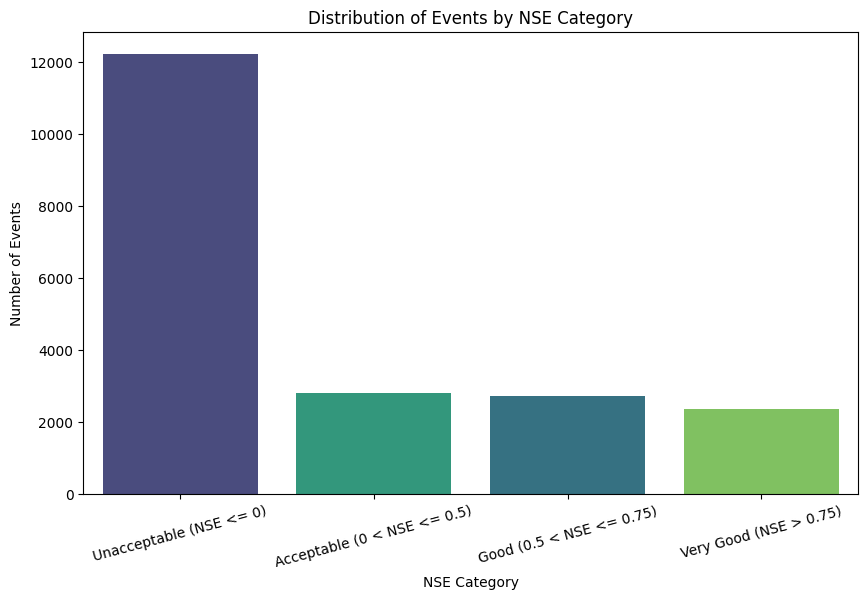

--- Events per Watershed Summary ---
Number of initial watersheds: 409
Number of watersheds with at least one acceptable event: 298

Statistics for the number of acceptable events per watershed:
count    298.00
mean      26.38
std       35.21
min        1.00
25%        3.25
50%       11.00
75%       35.75
max      209.00
Name: n_acceptable_events, dtype: float64

--- Analyzing Drivers of Unacceptable Model Fits (NSE <= 0) ---

Top 10 characteristics driving model performance (from Logistic Regression):
                    feature  coefficient  abs_coefficient
6            peak_quickflow     7.583405         7.583405
5        event_duration_min     1.554112         1.554112
1    total_precipitation_mm    -0.821190         0.821190
3              response_min    -0.260165         0.260165
8   ppt_spatial_variability    -0.178998         0.178998
14            ppt_prior_24h     0.161299         0.161299
4          ppt_dutation_min    -0.084038         0.084038
13             ppt_prior_3d 

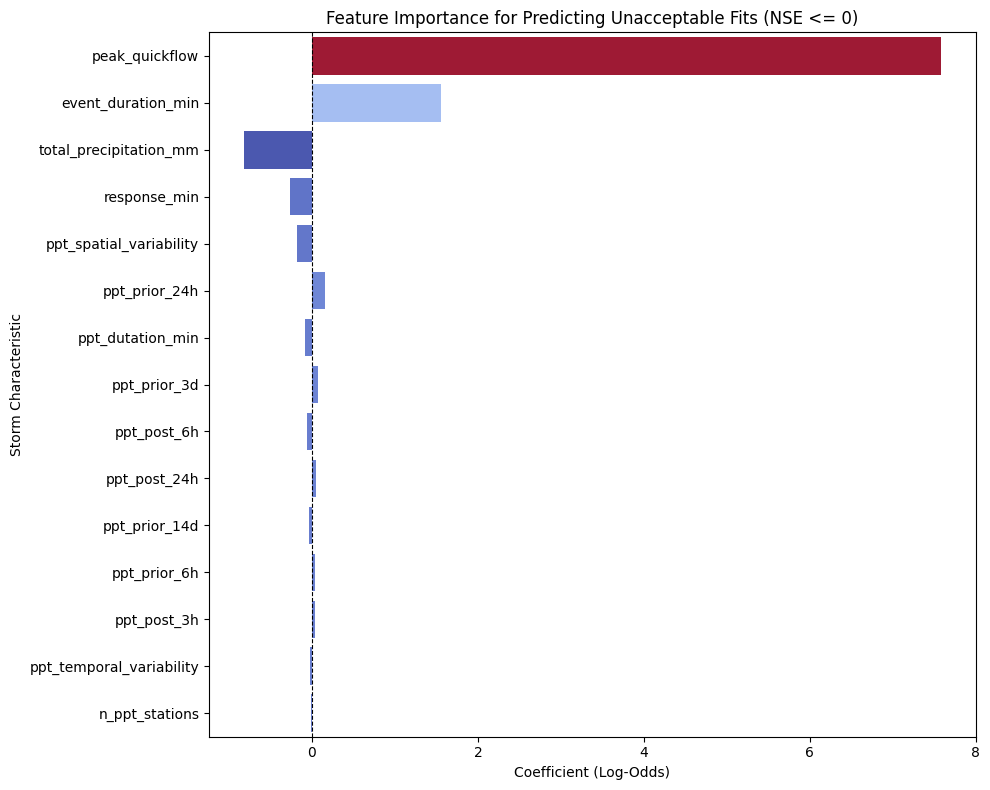


--- Final Assessment ---
Total events processed: 20092
Number of unacceptable events (NSE <= 0): 12231 (60.9%)
Number of suitable events for next steps (NSE > 0): 7861 (39.1%)


In [3]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

#-------------------------------------------------------------------------------
## Step 1: Categorize NSE and Initial Summaries
#-------------------------------------------------------------------------------

# Define the function to categorize NSE
def categorize_nse(nse):
    if nse > 0.75:
        return 'Very Good (NSE > 0.75)'
    elif 0.50 < nse <= 0.75:
        return 'Good (0.5 < NSE <= 0.75)'
    elif 0.0 < nse <= 0.50:
        return 'Acceptable (0 < NSE <= 0.5)'
    else:
        return 'Unacceptable (NSE <= 0)'

# Apply the function to create the category column
df_events['nse_category'] = df_events['NSE'].apply(categorize_nse)

# --- Visualization 1: Overall Distribution of NSE Categories ---
print("--- Overall Event Quality Summary ---")
print(f"Total number of events: {len(df_events)}")
category_counts = df_events['nse_category'].value_counts()
print(category_counts)
print("\n")

plt.figure(figsize=(10, 6))
sns.countplot(
    x='nse_category',
    hue='nse_category',
    legend=False,
    data=df_events,
    order=category_counts.index,
    palette='viridis'
)
plt.title('Distribution of Events by NSE Category')
plt.xlabel('NSE Category')
plt.ylabel('Number of Events')
plt.xticks(rotation=15)
plt.show()

# --- Summary 2: Distribution of Acceptable/Unacceptable Events by Watershed ---
print("--- Events per Watershed Summary ---")
# Filter for events that are suitable for the next steps (NSE > 0)
acceptable_events = df_events[df_events['NSE'] > 0]
watershed_summary = acceptable_events.groupby('ws_id').size().to_frame('n_acceptable_events')
print("Number of initial watersheds:",  df_events['ws_id'].nunique())
print("Number of watersheds with at least one acceptable event:", len(watershed_summary))
print("\nStatistics for the number of acceptable events per watershed:")
print(watershed_summary['n_acceptable_events'].describe().round(2))

#-------------------------------------------------------------------------------
## Step 2: Logistic Regression to Analyze Unacceptable Fits
#-------------------------------------------------------------------------------
print("\n--- Analyzing Drivers of Unacceptable Model Fits (NSE <= 0) ---")

# Define the binary target variable
df_events['is_unacceptable'] = (df_events['NSE'] <= 0).astype(int)

# Define features (X) and target (y)
# Exclude identifiers, dates, and the target/optimization variables
features_to_exclude = [
    'event_start', 'event_end', 'ppt_start', 'ppt_end', 'storm_id', 'ws_id',
    'NSE', 'nse_category', 'is_unacceptable',
    'Tc', 'R', 'initial_loss_mm', 'constant_loss_mm_hr' # Exclude optimized params
]
features = [col for col in df_events.columns if col not in features_to_exclude]
X = df_events[features]
y = df_events['is_unacceptable']

# Handle potential missing values in features
X = X.fillna(X.median())

# Split data and scale features
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the logistic regression model with balanced class weights
log_reg = LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# --- Analysis 3: Identify Key Drivers from Model Coefficients ---
# Create a DataFrame of the coefficients to identify key drivers
coefficients = pd.DataFrame({
    'feature': features,
    'coefficient': log_reg.coef_[0]
})
# A positive coefficient means the feature increases the odds of an 'unacceptable' fit
coefficients['abs_coefficient'] = np.abs(coefficients['coefficient'])
coefficients = coefficients.sort_values(by='abs_coefficient', ascending=False)

print("\nTop 10 characteristics driving model performance (from Logistic Regression):")
print(coefficients.head(10))

# --- Visualization 2: Feature Importance Plot ---
plt.figure(figsize=(10, 8))
sns.barplot(
    x='coefficient',
    y='feature',
    data=coefficients.head(15), # Plot top 15 features
    palette='coolwarm',
    hue='coefficient',
    legend=False,
    orient='h'
)
plt.title('Feature Importance for Predicting Unacceptable Fits (NSE <= 0)')
plt.xlabel('Coefficient (Log-Odds)')
plt.ylabel('Storm Characteristic')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()

# --- Final Summary ---
n_total = len(df_events)
n_unacceptable = category_counts.get('Unacceptable (NSE <= 0)', 0)
n_acceptable = n_total - n_unacceptable
print(f"\n--- Final Assessment ---")
print(f"Total events processed: {n_total}")
print(f"Number of unacceptable events (NSE <= 0): {n_unacceptable} ({n_unacceptable/n_total:.1%})")
print(f"Number of suitable events for next steps (NSE > 0): {n_acceptable} ({n_acceptable/n_total:.1%})")

##### Analysis

The large, positive coefficient for peak_quickflow (+7.58) strongly indicates that events with higher peak flows are significantly more likely to result in an unacceptable model fit.

**Key Insights**
1. High-Intensity, Flashy Storms are Poorly Modeled: This is the main story. The model struggles with extreme events.

    - `peak_quickflow` (+7.58): The strongest predictor. The model's linear routing assumptions likely break down during very high flows, failing to capture the complex, non-linear behavior of a watershed during a major flood.

    - `total_precipitation_mm` (-0.82): A negative coefficient here is interesting. It suggests that for a given peak flow, storms with more total rainfall (i.e., longer, less intense storms) are modeled better. This reinforces the idea that it's the "flashiness" (high peak for a given volume) that causes the model to fail, not just the total amount of water.

    - `Event Duration`(+1.55): Longer event duration tends to have longer recession limb. As identified before, the model strugles to accurately predict reccession limb. 

2. Dropped watersheds: 111 watersheds was dropped for not having at leat one acceptable event. As it might be a bigger watersheds with high peak flows, it also possible those watersheds was not delineated in high quality. 

**Further Analysis**
It is important to further understand the magnitute the model starts struggling to efficiently capture the the peakflow and also to test the hypothesis of bad delineated watersheds is responsible for the model struggles to capture storm events for these watersheds. 


--- Failure Rate by Peak Quickflow Bin ---
   mean_peak_flow  failure_rate  n_events
0        0.054573     38.855721      2010
1        0.299753     32.105525      2009
2        0.875532     33.947237      2009
3        2.067789     45.296167      2009
4        4.280726     53.111000      2009
5        8.507978     62.767546      2009
6       16.622519     74.166252      2009
7       32.696117     82.329517      2009
8       73.361375     89.298158      2009
9      369.257158     96.865672      2010


/var/folders/6x/tz4_svyx1mv9mc68z3jl0_s00000gn/T/ipykernel_33146/4112836746.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned_analysis = df_events.groupby('peak_flow_bin').agg(
/var/folders/6x/tz4_svyx1mv9mc68z3jl0_s00000gn/T/ipykernel_33146/4112836746.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


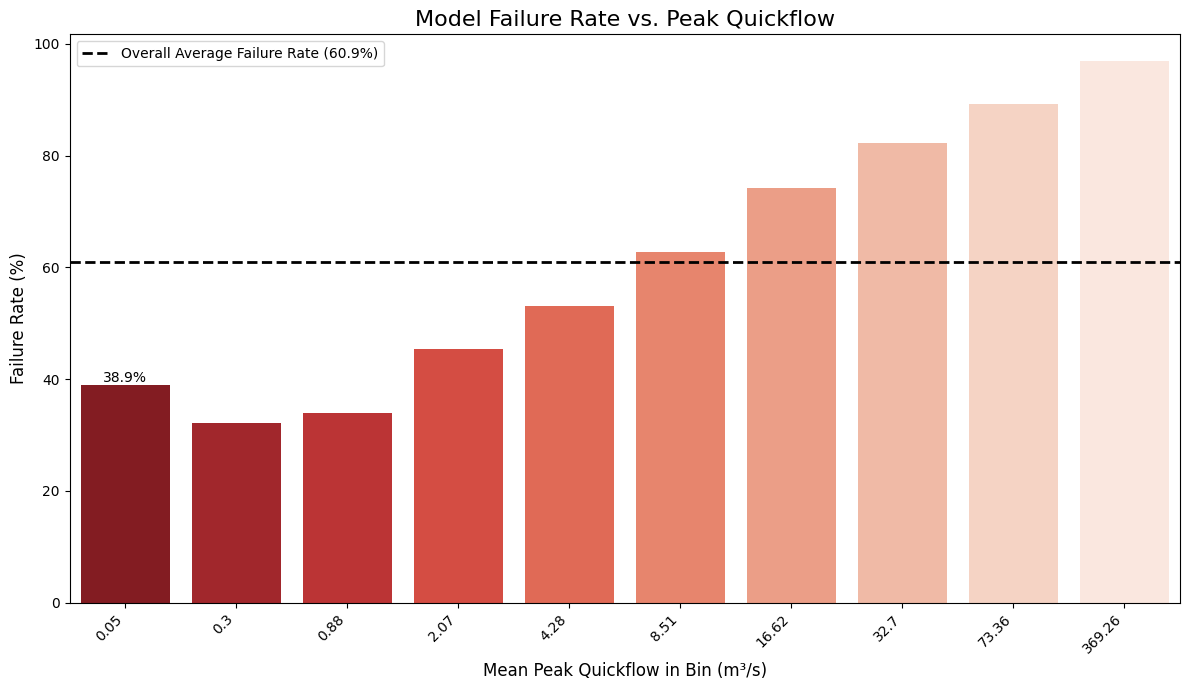

In [4]:
# --- Assume df_events is a pre-existing pandas DataFrame ---
# It must contain 'peak_quickflow' and 'is_unacceptable' columns.

#-------------------------------------------------------------------------------
## Analysis: Peak Flow vs. Model Failure Rate
#-------------------------------------------------------------------------------

# Define the number of bins (deciles are a good start)
N_BINS = 10

# Create quantile-based bins for the 'peak_quickflow' column
df_events['peak_flow_bin'] = pd.qcut(
    df_events['peak_quickflow'],
    q=N_BINS,
    duplicates='drop' # Handles cases where bin edges are not unique
)

# Group by the new bins and calculate the failure rate for each
# We also calculate the mean peak flow in each bin for a cleaner plot label
binned_analysis = df_events.groupby('peak_flow_bin').agg(
    failure_rate=('is_unacceptable', 'mean'),
    mean_peak_flow=('peak_quickflow', 'mean'),
    n_events=('storm_id', 'count') # Assuming a 'storm_id' or any unique identifier
).reset_index()

# Convert failure rate to percentage for better readability
binned_analysis['failure_rate'] *= 100

print("--- Failure Rate by Peak Quickflow Bin ---")
print(binned_analysis[['mean_peak_flow', 'failure_rate', 'n_events']])


# --- Visualization ---
plt.figure(figsize=(12, 7))
ax = sns.barplot(
    x=binned_analysis['mean_peak_flow'].round(2), # Use mean flow for clean x-axis labels
    y=binned_analysis['failure_rate'],
    palette='Reds_r'
)

# Add annotations and titles
plt.title('Model Failure Rate vs. Peak Quickflow', fontsize=16)
plt.xlabel('Mean Peak Quickflow in Bin (m³/s)', fontsize=12)
plt.ylabel('Failure Rate (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
ax.bar_label(ax.containers[0], fmt='%.1f%%') # Add percentage labels on bars

# Add a line for the overall average failure rate for context
overall_failure_rate = df_events['is_unacceptable'].mean() * 100
plt.axhline(
    y=overall_failure_rate,
    color='black',
    linestyle='--',
    linewidth=2,
    label=f'Overall Average Failure Rate ({overall_failure_rate:.1f}%)'
)

plt.legend()
plt.tight_layout()
plt.show()

--- Data Merged ---
Total events with distance data: 20092

--- Hypothesis Test 1: Independent T-test ---
Mean distance for UNACCEPTABLE fits: 109.10 m
Mean distance for ACCEPTABLE fits: 54.40 m

T-statistic: 37.6550
P-value: 0.0000

Conclusion: The result is statistically significant.
The mean distance for unacceptable events is significantly different from acceptable events, supporting the hypothesis.

--- Hypothesis Test 2: Binned Failure Rate Visualization ---
Failure Rate by Snapping Distance Bin:
   mean_distance  failure_rate
0      19.004752     47.864563
1      19.355598     59.753593
2      19.595675     40.127898
3      19.791716     41.955836
4      40.681732     59.718310
5      71.168977     81.513599
6     169.720612     75.910364
7     344.334588     80.632253


/var/folders/6x/tz4_svyx1mv9mc68z3jl0_s00000gn/T/ipykernel_33146/3010253003.py:79: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned_dist_analysis = df_merged_dist.groupby('distance_bin').agg(
/var/folders/6x/tz4_svyx1mv9mc68z3jl0_s00000gn/T/ipykernel_33146/3010253003.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


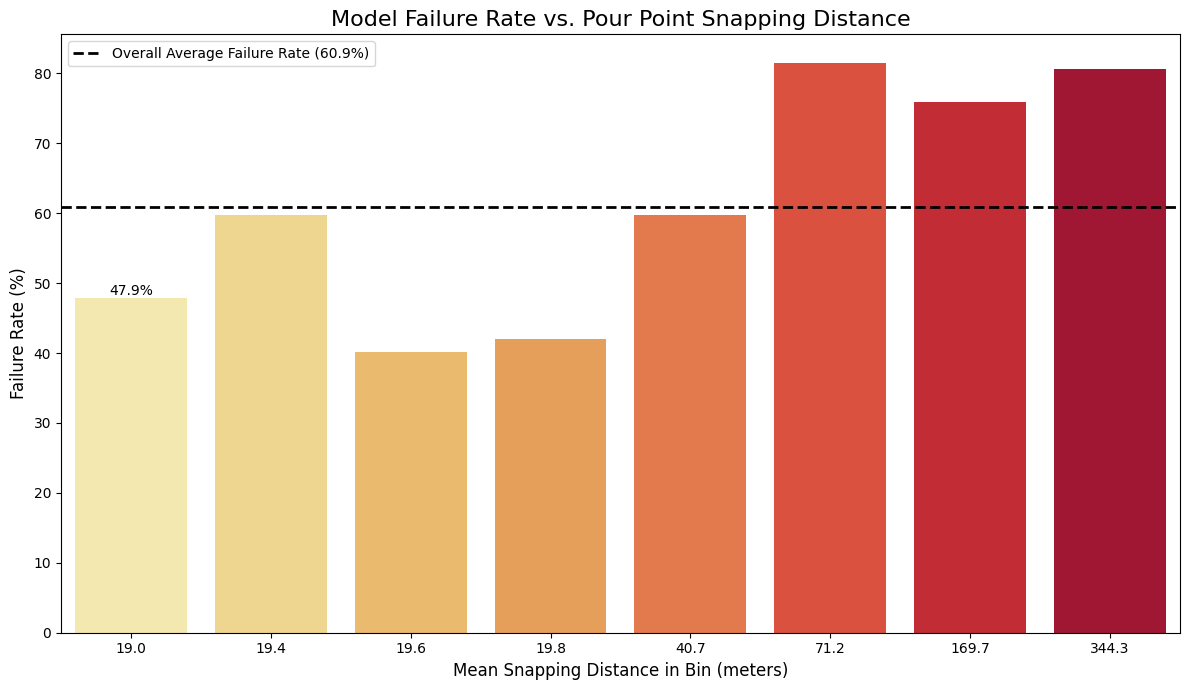

In [5]:
from scipy import stats
import geopandas as gpd

# Loand distance points between actual station geo point and
# Point used to delineate the watershed
watersheds_vector_dir_path = PROJECT_ROOT / "data/gold/geo/gpkg/watersheds"
unique_ws_id = df_events['ws_id'].unique()
watershed_vector_list_path = list(watersheds_vector_dir_path.glob("*.gpkg"))

ws_id_list = []
distance_betweeen_points_list = []
for ws_id in unique_ws_id:
    catch_path = watersheds_vector_dir_path / f"catchment_{ws_id}.gpkg"
    if catch_path.exists():
        catch = gpd.read_file(catch_path)
        distance = catch['distance_between_points_m'].iloc[0]
        ws_id_list.append(ws_id)
        distance_betweeen_points_list.append(distance)
    else:
        continue
df_distance_points = pd.DataFrame({
    'ws_id': ws_id_list,
    'distance_m': distance_betweeen_points_list
})

# --- Assume df_events and df_distance_points are pre-existing DataFrames ---

#-------------------------------------------------------------------------------
## Step 1: Merge Event Performance with Delineation Distance Data
#-------------------------------------------------------------------------------

# Merge the two dataframes
df_merged_dist = pd.merge(df_events, df_distance_points, on='ws_id', how='left')

# Drop any events for which distance data was not available
df_merged_dist.dropna(subset=['distance_m'], inplace=True)

print("--- Data Merged ---")
print(f"Total events with distance data: {len(df_merged_dist)}\n")

#-------------------------------------------------------------------------------
## Step 2: Statistical Test (Independent T-test)
#-------------------------------------------------------------------------------
print("--- Hypothesis Test 1: Independent T-test ---")

# Separate the distances into two groups based on model performance
dist_unacceptable = df_merged_dist[df_merged_dist['is_unacceptable'] == 1]['distance_m']
dist_acceptable = df_merged_dist[df_merged_dist['is_unacceptable'] == 0]['distance_m']

print(f"Mean distance for UNACCEPTABLE fits: {dist_unacceptable.mean():.2f} m")
print(f"Mean distance for ACCEPTABLE fits: {dist_acceptable.mean():.2f} m\n")

# Perform the t-test
t_stat, p_value = stats.ttest_ind(dist_unacceptable, dist_acceptable, equal_var=False, nan_policy='omit')

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# Interpret the result
SIGNIFICANCE_LEVEL = 0.05
if p_value < SIGNIFICANCE_LEVEL:
    print("\nConclusion: The result is statistically significant.")
    print("The mean distance for unacceptable events is significantly different from acceptable events, supporting the hypothesis.\n")
else:
    print("\nConclusion: The result is not statistically significant.")
    print("There is not enough evidence to say the mean distance is different between the groups.\n")


#-------------------------------------------------------------------------------
## Step 3: Visual Analysis (Binned Failure Rate)
#-------------------------------------------------------------------------------
print("--- Hypothesis Test 2: Binned Failure Rate Visualization ---")

# Create quantile-based bins for the distance
N_BINS = 8 # Can be adjusted
df_merged_dist['distance_bin'] = pd.qcut(df_merged_dist['distance_m'], q=N_BINS, duplicates='drop')

# Group by bins and calculate the failure rate
binned_dist_analysis = df_merged_dist.groupby('distance_bin').agg(
    failure_rate=('is_unacceptable', 'mean'),
    mean_distance=('distance_m', 'mean')
).reset_index()

binned_dist_analysis['failure_rate'] *= 100 # Convert to percentage

print("Failure Rate by Snapping Distance Bin:")
print(binned_dist_analysis[['mean_distance', 'failure_rate']])

# --- Visualization ---
plt.figure(figsize=(12, 7))
ax = sns.barplot(
    x=binned_dist_analysis['mean_distance'].round(1),
    y=binned_dist_analysis['failure_rate'],
    palette='YlOrRd'
)

plt.title('Model Failure Rate vs. Pour Point Snapping Distance', fontsize=16)
plt.xlabel('Mean Snapping Distance in Bin (meters)', fontsize=12)
plt.ylabel('Failure Rate (%)', fontsize=12)
ax.bar_label(ax.containers[0], fmt='%.1f%%')

# Add a line for the overall average failure rate for context
overall_failure_rate = df_merged_dist['is_unacceptable'].mean() * 100
plt.axhline(
    y=overall_failure_rate,
    color='black',
    linestyle='--',
    linewidth=2,
    label=f'Overall Average Failure Rate ({overall_failure_rate:.1f}%)'
)
plt.legend()
plt.tight_layout()
plt.show()

##### Analysis

Both the hypothesis of greater peak flow and great distance between original station geo point and snapped points used to delinate the watershed, significatly influence the model perfomance, **are true**.

The limit in peabetween what the model is capable of efficiently capturing is about between 0.88 and 2 cubic meters per second. **Therefore the model may not be suitable for predicting response with storm events which generates runoff greater than 2 cubic meters per second.** 

The average distance for acceptable events is 54m, while 109m for unacceptable events. T-test statistic score is significant between the two population,  with p-value aproximately 0. 

### 2. Data Cleaning and Filtering

--- Initial State (Before Cleaning) ---
Number of events with NSE >= 0.5: 5056
Number of watersheds with at least one event: 253


--- After Outlier Removal ---
Number of events remaining after outlier removal: 4346
Number of watersheds remaining: 253
Total events removed as outliers: 710




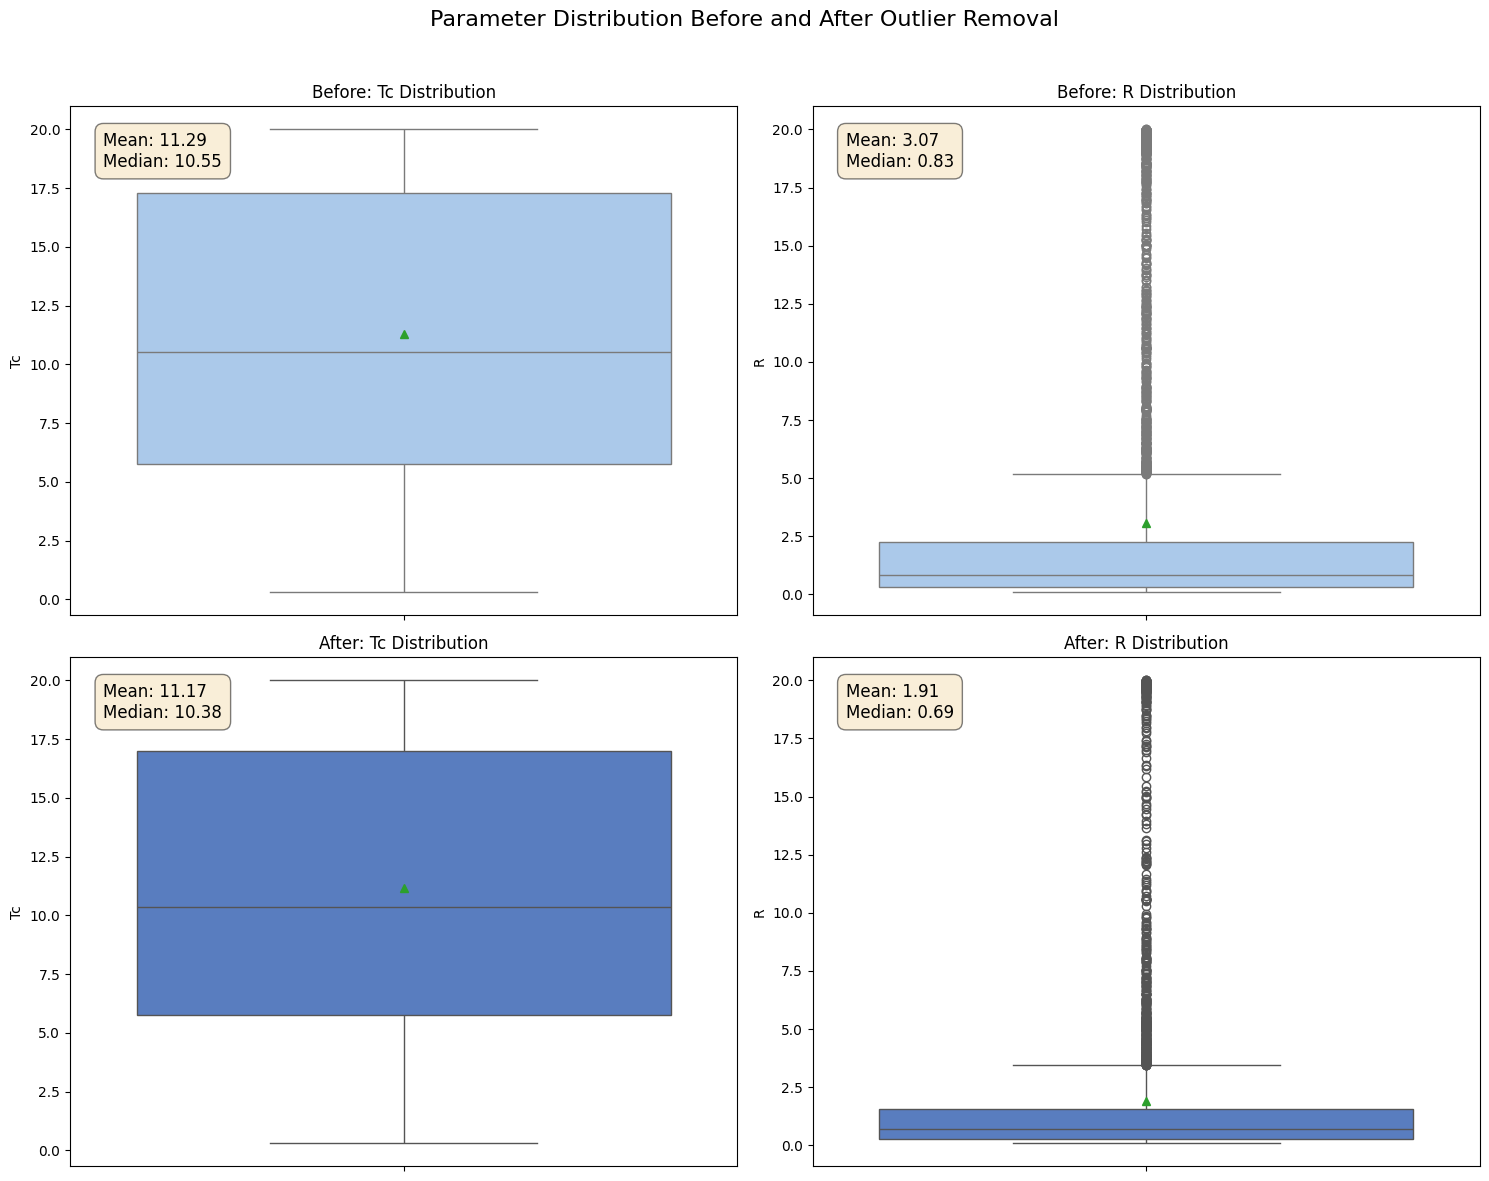

--- After Filtering Watersheds by Event Count ---
Final number of events for analysis: 4248
Final number of watersheds with >= 3 events: 183
Total watersheds removed due to low event count: 70




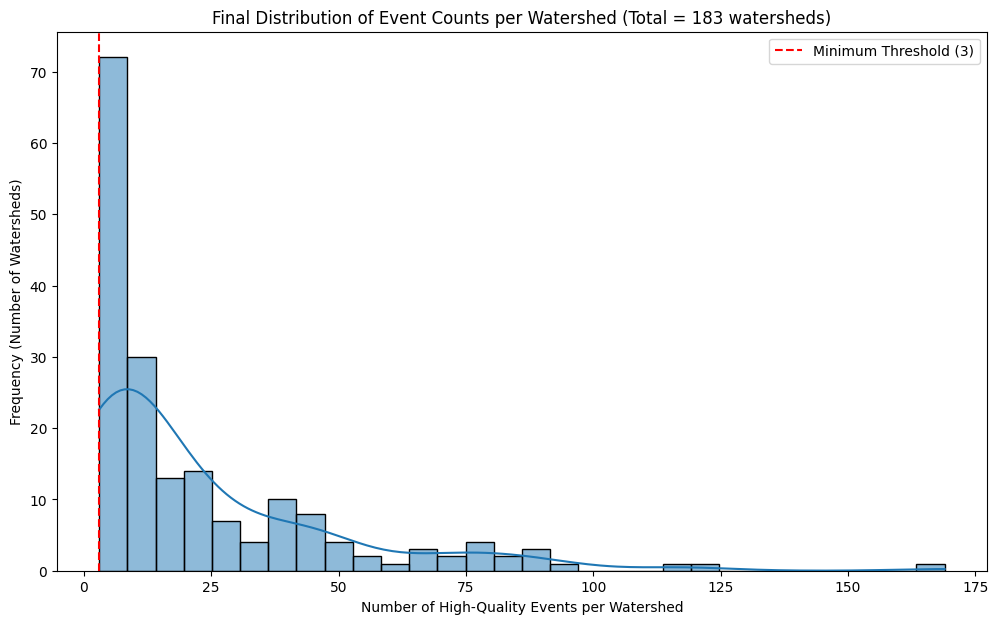

Data cleaning and filtering step is complete.
The resulting DataFrame 'df_filtered' is ready for the next step.


In [6]:
import warnings
warnings.filterwarnings("ignore")
#-------------------------------------------------------------------------------
## Step 1: Initial Filtering for High-Quality Events
#-------------------------------------------------------------------------------

NSE_THRESHOLD = 0.5
# Filter events with acceptable performance (NSE >= NSE_THRESHOLD).
# We will call this the 'candidate' dataset for outlier removal.
df_candidates = df_events[df_events['NSE'] >= NSE_THRESHOLD].copy()

print("--- Initial State (Before Cleaning) ---")
print(f"Number of events with NSE >= {NSE_THRESHOLD}: {len(df_candidates)}")
print(f"Number of watersheds with at least one event: {df_candidates['ws_id'].nunique()}")
print("\n")


#-------------------------------------------------------------------------------
## Step 2: Removing Outliers using the IQR Method per Watershed
#-------------------------------------------------------------------------------

def remove_outliers_iqr(group):
    """
    Applies the IQR outlier removal method to the Tc and R columns of a dataframe group.
    An event is removed if it's an outlier for EITHER Tc or R.
    """
    # Calculate IQR for Tc
    Q1_tc = group['Tc'].quantile(0.25)
    Q3_tc = group['Tc'].quantile(0.75)
    IQR_tc = Q3_tc - Q1_tc
    lower_bound_tc = Q1_tc - 1.5 * IQR_tc
    upper_bound_tc = Q3_tc + 1.5 * IQR_tc

    # Calculate IQR for R
    Q1_r = group['R'].quantile(0.25)
    Q3_r = group['R'].quantile(0.75)
    IQR_r = Q3_r - Q1_r
    lower_bound_r = Q1_r - 1.5 * IQR_r
    upper_bound_r = Q3_r + 1.5 * IQR_r

    # Filter the group
    filtered_group = group[
        (group['Tc'] >= lower_bound_tc) & (group['Tc'] <= upper_bound_tc) &
        (group['R'] >= lower_bound_r) & (group['R'] <= upper_bound_r)
    ]
    return filtered_group

# Apply the function to each watershed group
# Note: The group_keys=False prevents the ws_id from becoming the index.
df_no_outliers = df_candidates.groupby('ws_id',group_keys=False).apply(remove_outliers_iqr)

print("--- After Outlier Removal ---")
print(f"Number of events remaining after outlier removal: {len(df_no_outliers)}")
print(f"Number of watersheds remaining: {df_no_outliers['ws_id'].nunique()}")
print(f"Total events removed as outliers: {len(df_candidates) - len(df_no_outliers)}")
print("\n")


# --- Visualization 1: Before and After Outlier Removal ---
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Parameter Distribution Before and After Outlier Removal', fontsize=16)

# --- Before Tc ---
mean_before_tc = df_candidates['Tc'].mean()
median_before_tc = df_candidates['Tc'].median()
sns.boxplot(data=df_candidates, y='Tc', ax=axes[0, 0], palette='pastel', showmeans=True)
axes[0, 0].set_title('Before: Tc Distribution')
# Add text annotation
axes[0, 0].text(0.05, 0.95, f'Mean: {mean_before_tc:.2f}\nMedian: {median_before_tc:.2f}',
                transform=axes[0, 0].transAxes, fontsize=12, verticalalignment='top',
                bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

# --- Before R ---
mean_before_r = df_candidates['R'].mean()
median_before_r = df_candidates['R'].median()
sns.boxplot(data=df_candidates, y='R', ax=axes[0, 1], palette='pastel', showmeans=True)
axes[0, 1].set_title('Before: R Distribution')
# Add text annotation
axes[0, 1].text(0.05, 0.95, f'Mean: {mean_before_r:.2f}\nMedian: {median_before_r:.2f}',
                transform=axes[0, 1].transAxes, fontsize=12, verticalalignment='top',
                bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

# --- After Tc ---
mean_after_tc = df_no_outliers['Tc'].mean()
median_after_tc = df_no_outliers['Tc'].median()
sns.boxplot(data=df_no_outliers, y='Tc', ax=axes[1, 0], palette='muted', showmeans=True)
axes[1, 0].set_title('After: Tc Distribution')
# Add text annotation
axes[1, 0].text(0.05, 0.95, f'Mean: {mean_after_tc:.2f}\nMedian: {median_after_tc:.2f}',
                transform=axes[1, 0].transAxes, fontsize=12, verticalalignment='top',
                bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

# --- After R ---
mean_after_r = df_no_outliers['R'].mean()
median_after_r = df_no_outliers['R'].median()
sns.boxplot(data=df_no_outliers, y='R', ax=axes[1, 1], palette='muted', showmeans=True)
axes[1, 1].set_title('After: R Distribution')
# Add text annotation
axes[1, 1].text(0.05, 0.95, f'Mean: {mean_after_r:.2f}\nMedian: {median_after_r:.2f}',
                transform=axes[1, 1].transAxes, fontsize=12, verticalalignment='top',
                bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


#-------------------------------------------------------------------------------
## Step 3: Excluding Watersheds with Fewer than 5 Events
#-------------------------------------------------------------------------------

# Calculate the number of events per watershed in the cleaned dataframe
event_counts = df_no_outliers.groupby('ws_id')['ws_id'].transform('size')

# Filter out watersheds with fewer than 5 events
MINIMUM_EVENTS = 3
df_filtered = df_no_outliers[event_counts >= MINIMUM_EVENTS]

print("--- After Filtering Watersheds by Event Count ---")
print(f"Final number of events for analysis: {len(df_filtered)}")
print(f"Final number of watersheds with >= {MINIMUM_EVENTS} events: {df_filtered['ws_id'].nunique()}")
print(f"Total watersheds removed due to low event count: {df_no_outliers['ws_id'].nunique() - df_filtered['ws_id'].nunique()}")
print("\n")

# --- Visualization 2: Final Distribution of Event Counts per Watershed ---
plt.figure(figsize=(12, 7))
final_counts = df_filtered.groupby('ws_id').size()
sns.histplot(final_counts, bins=30, kde=True)
plt.title(f'Final Distribution of Event Counts per Watershed (Total = {len(final_counts)} watersheds)')
plt.xlabel('Number of High-Quality Events per Watershed')
plt.ylabel('Frequency (Number of Watersheds)')
plt.axvline(MINIMUM_EVENTS, color='red', linestyle='--', label=f'Minimum Threshold ({MINIMUM_EVENTS})')
plt.legend()
plt.show()


# The final, cleaned DataFrame is df_filtered
print("Data cleaning and filtering step is complete.")
print("The resulting DataFrame 'df_filtered' is ready for the next step.")

##### Analysis

The most significant change in data after removing outliers it the number of unique watersheds present in data: it dropped **from 298 to 183** after removing outliers and watersheed with less than three storm evets. Probably they might be poor delineated watersheds. Still there is watershed with nearly 170 good quality calibrated storm event, probably reflecting good quality data for this watershed. 

### 3. Ivestigating Temporal Trends

--- Preparing Land Cover Data ---
Land cover data aggregated and processed.

--- Preparing and Merging Event Data ---
Merged dataframe created with 3561 events.

--- Performing Statistical Analysis for Each Watershed ---
Statistical analysis complete.

--- Summary of Temporal Trend Analysis ---
      ws_id  anova_p_value_tc  anova_p_value_r  corr_coeff_tc  \
0  03011800          0.668313         0.388071            NaN   
1  03026480          0.671713         0.000986            NaN   
2  03026500          0.770930         0.799858            NaN   
3  03044810          0.660675         0.344365            NaN   
4  03049800          0.931192         0.399280       0.701738   

   corr_p_value_tc  corr_coeff_r  corr_p_value_r  significant_tc  \
0              NaN           NaN             NaN           False   
1              NaN           NaN             NaN           False   
2              NaN           NaN             NaN           False   
3              NaN           NaN         

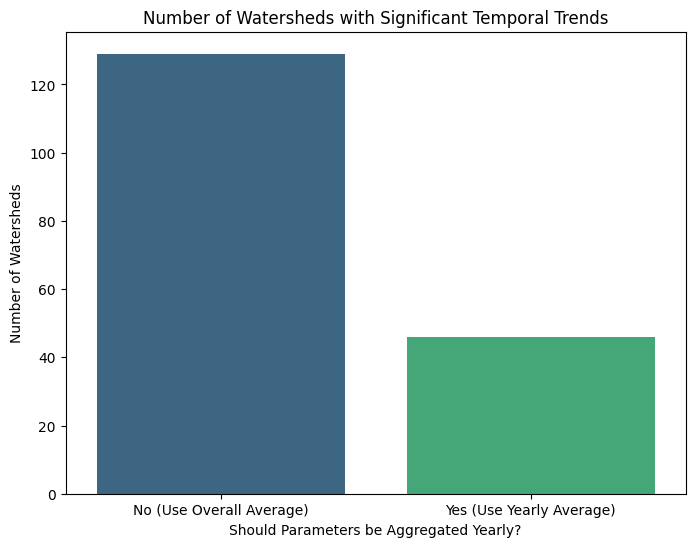


Analysis of temporal trends is complete.
The 'df_analysis' DataFrame contains the decision for each watershed.


In [7]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# df_filtered: From the previous step, containing 'ws_id', 'Tc', 'R', 'event_start'
# df_land_cover: Contains 'ws_id', 'year', and 'lc_code_...' columns

#-------------------------------------------------------------------------------
## Step 1: Prepare Land Cover Data
#-------------------------------------------------------------------------------
print("--- Preparing Land Cover Data ---")

# Define the aggregation mapping
lc_aggregation_map = {
    'pct_developed': [21, 22, 23, 24],
    'pct_forest': [41, 42, 43],
    'pct_agriculture': [81, 82],
    'pct_grass_scrub': [52, 71],
    'pct_wetlands': [90, 95],
    'pct_water': [11],
    'pct_barren': [31]
}

# Aggregate the land cover codes
# The columns output will be the percentage of each category
for category, codes in lc_aggregation_map.items():
    lc_cols = [f'lc_code_{code}' for code in codes]
    df_land_cover[category] = df_land_cover[lc_cols].sum(axis=1)

# Create a clean, yearly land cover dataframe
df_lc_yearly = df_land_cover[['ws_id', 'year', 'pct_developed']].copy()
print("Land cover data aggregated and processed.\n")


#-------------------------------------------------------------------------------
## Step 2: Prepare and Merge Event Data
#-------------------------------------------------------------------------------
print("--- Preparing and Merging Event Data ---")

# Ensure event_start is a datetime object and extract year
df_filtered['event_start'] = pd.to_datetime(df_filtered['event_start'])
df_filtered['year'] = df_filtered['event_start'].dt.year

# Merge event data with yearly land cover data
df_merged = pd.merge(df_filtered, df_lc_yearly, on=['ws_id', 'year'], how='left')

# Drop events where land cover data was not available for that year
df_merged.dropna(subset=['pct_developed'], inplace=True)
print(f"Merged dataframe created with {len(df_merged)} events.\n")


#-------------------------------------------------------------------------------
## Step 3: Perform Statistical Analysis per Watershed
#-------------------------------------------------------------------------------
print("--- Performing Statistical Analysis for Each Watershed ---")

analysis_results = []
# Get list of watersheds that have data for more than one year
watersheds_to_analyze = df_merged.groupby('ws_id').filter(lambda x: x['year'].nunique() > 1)['ws_id'].unique()

for ws_id in watersheds_to_analyze:
    ws_data = df_merged[df_merged['ws_id'] == ws_id]

    # --- ANOVA Test ---
    # Prepare data for ANOVA: list of arrays, one array of Tc/R values per year
    yearly_groups_tc = [group['Tc'].values for name, group in ws_data.groupby('year')]
    yearly_groups_r = [group['R'].values for name, group in ws_data.groupby('year')]

    # Run ANOVA only if there are at least 2 years of data
    p_anova_tc = stats.f_oneway(*yearly_groups_tc).pvalue if len(yearly_groups_tc) >= 2 else None
    p_anova_r = stats.f_oneway(*yearly_groups_r).pvalue if len(yearly_groups_r) >= 2 else None

    # --- Correlation Analysis ---
    # Aggregate data to yearly means for correlation
    yearly_summary = ws_data.groupby('year').agg(
        mean_tc=('Tc', 'mean'),
        mean_r=('R', 'mean'),
        pct_developed=('pct_developed', 'first') # 'first' is fine since it's constant within the year
    ).reset_index()

    # Run correlation only if there are at least 3 years of data
    if len(yearly_summary) >= 3:
        corr_tc = stats.pearsonr(yearly_summary['pct_developed'], yearly_summary['mean_tc'])
        corr_r = stats.pearsonr(yearly_summary['pct_developed'], yearly_summary['mean_r'])
    else:
        corr_tc = (np.nan, np.nan)
        corr_r = (np.nan, np.nan)

    analysis_results.append({
        'ws_id': ws_id,
        'anova_p_value_tc': p_anova_tc,
        'anova_p_value_r': p_anova_r,
        'corr_coeff_tc': corr_tc[0],
        'corr_p_value_tc': corr_tc[1],
        'corr_coeff_r': corr_r[0],
        'corr_p_value_r': corr_r[1]
    })

df_analysis = pd.DataFrame(analysis_results)

# --- Determine if aggregation should be by year ---
SIGNIFICANCE_LEVEL = 0.05
df_analysis['significant_tc'] = (df_analysis['anova_p_value_tc'] < SIGNIFICANCE_LEVEL) | (df_analysis['corr_p_value_tc'] < SIGNIFICANCE_LEVEL)
df_analysis['significant_r'] = (df_analysis['anova_p_value_r'] < SIGNIFICANCE_LEVEL) | (df_analysis['corr_p_value_r'] < SIGNIFICANCE_LEVEL)
df_analysis['aggregate_by_year'] = df_analysis['significant_tc'] | df_analysis['significant_r']

print("Statistical analysis complete.\n")


#-------------------------------------------------------------------------------
## Step 4: Summarize and Visualize Results
#-------------------------------------------------------------------------------
print("--- Summary of Temporal Trend Analysis ---")
print(df_analysis.head())
print("\n")

summary_counts = df_analysis['aggregate_by_year'].value_counts()
print("Decision on how to aggregate parameters:")
print(summary_counts)

# --- Visualization ---
plt.figure(figsize=(8, 6))
sns.countplot(x='aggregate_by_year', data=df_analysis, palette='viridis')
plt.title('Number of Watersheds with Significant Temporal Trends')
plt.xlabel('Should Parameters be Aggregated Yearly?')
plt.ylabel('Number of Watersheds')
plt.xticks([False, True], ['No (Use Overall Average)', 'Yes (Use Yearly Average)'])
plt.show()

# The final outputs are df_analysis and df_merged, which will be used in the next step.
print("\nAnalysis of temporal trends is complete.")
print("The 'df_analysis' DataFrame contains the decision for each watershed.")

### 4. Final Data Aggregation

--- Separating Watersheds for Aggregation ---
Watersheds to be aggregated yearly: 46
Watersheds to be aggregated with an overall average: 129

--- Processing Yearly-Aggregated Watersheds ---
Original watershed-year groups: 313
Watershed-year groups after CV filter: 272
Groups discarded due to high CV: 41

--- Processing Overall-Aggregated Watersheds ---


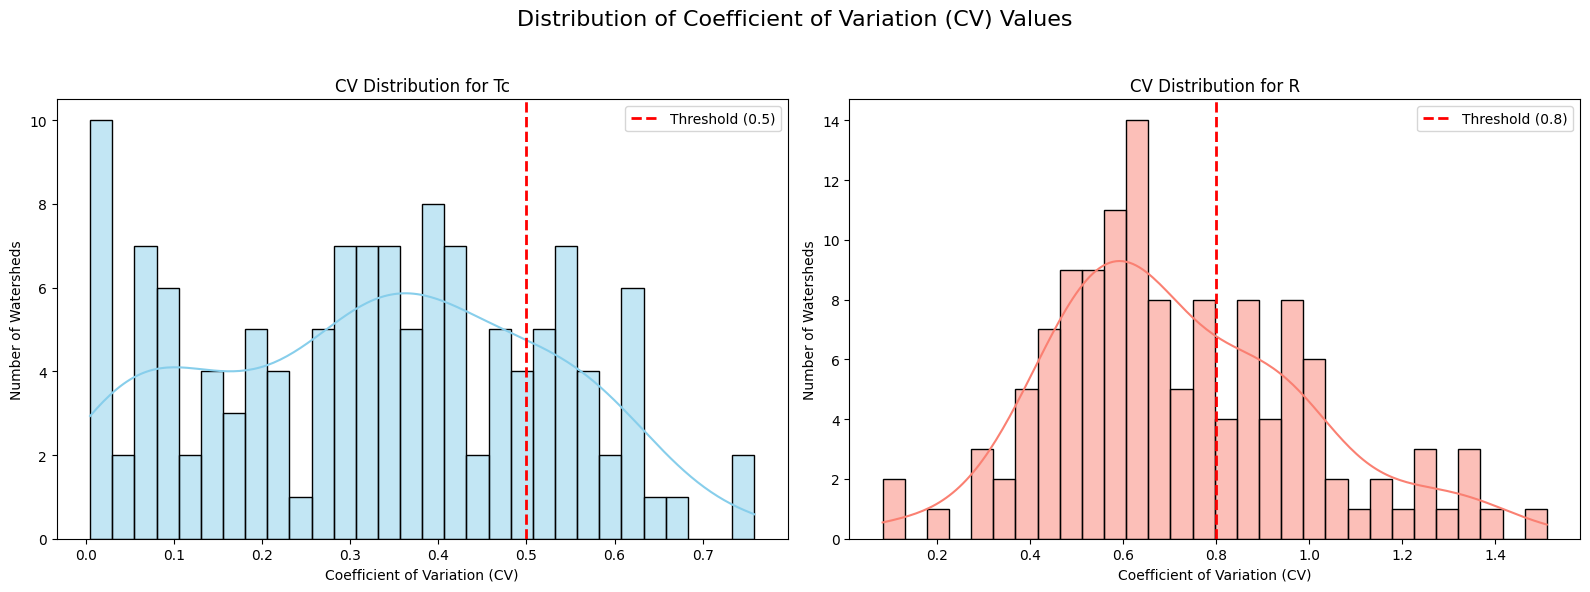

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Assume df_filtered, df_analysis, and df_lc_yearly are pre-existing DataFrames ---
# df_filtered: The cleaned event data (NSE >= NSE_THRESHOLD, outliers removed, etc.).
# df_analysis: The results from the temporal analysis, containing the 'aggregate_by_year' flag.
# df_lc_yearly: The prepared yearly land cover data with 'pct_developed'.

# Define the CV threshold for filtering
CV_THRESHOLD_TC = 0.5
CV_THRESHOLD_R = 0.8

#-------------------------------------------------------------------------------
## Step 1: Separate Watersheds Based on a Temporal Trend Analysis
#-------------------------------------------------------------------------------
print("--- Separating Watersheds for Aggregation ---")

# Get the list of watersheds to aggregate yearly vs. overall
ws_agg_yearly = df_analysis[df_analysis['aggregate_by_year'] == True]['ws_id'].unique()
ws_agg_overall = df_analysis[df_analysis['aggregate_by_year'] == False]['ws_id'].unique()

print(f"Watersheds to be aggregated yearly: {len(ws_agg_yearly)}")
print(f"Watersheds to be aggregated with an overall average: {len(ws_agg_overall)}\n")


#-------------------------------------------------------------------------------
## Step 2: Process Watersheds Requiring Yearly Aggregation
#-------------------------------------------------------------------------------
print("--- Processing Yearly-Aggregated Watersheds ---")

# Filter the events for this group
df_yearly_candidates = df_filtered[df_filtered['ws_id'].isin(ws_agg_yearly)]

# Group by watershed and year to calculate CV
grouped_yearly = df_yearly_candidates.groupby(['ws_id', 'year'])
cv_yearly = grouped_yearly.agg(
    cv_tc=('Tc', lambda x: np.std(x) / np.mean(x)),
    cv_r=('R', lambda x: np.std(x) / np.mean(x))
).reset_index()

# Identify valid groups that pass the CV check
valid_yearly_groups = cv_yearly[
    (cv_yearly['cv_tc'] < CV_THRESHOLD_TC) & (cv_yearly['cv_r'] < CV_THRESHOLD_R)
][['ws_id', 'year']]

# Filter the original candidates to keep only the valid groups
df_yearly_final_events = pd.merge(df_yearly_candidates, valid_yearly_groups, on=['ws_id', 'year'], how='inner')

# Aggregate the valid groups to get the final mean values
yearly_aggregated = df_yearly_final_events.groupby(['ws_id', 'year']).agg(
    Tc=('Tc', 'mean'),
    R=('R', 'mean')
).reset_index()

# Merge with land cover data to add features
df_final_yearly = pd.merge(yearly_aggregated, df_lc_yearly, on=['ws_id', 'year'], how='left')

print(f"Original watershed-year groups: {len(cv_yearly)}")
print(f"Watershed-year groups after CV filter: {len(df_final_yearly)}")
print(f"Groups discarded due to high CV: {len(cv_yearly) - len(df_final_yearly)}\n")

#-------------------------------------------------------------------------------
## Step 3: Process Watersheds Requiring Overall Aggregation
#-------------------------------------------------------------------------------
print("--- Processing Overall-Aggregated Watersheds ---")

# Filter the events for this group
df_overall_candidates = df_filtered[df_filtered['ws_id'].isin(ws_agg_overall)]

# Group by watershed to calculate CV
grouped_overall = df_overall_candidates.groupby('ws_id')
cv_overall = grouped_overall.agg(
    cv_tc=('Tc', lambda x: np.std(x) / np.mean(x)),
    cv_r=('R', lambda x: np.std(x) / np.mean(x))
).reset_index()


# --- Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Distribution of Coefficient of Variation (CV) Values', fontsize=16)

# Plot for CV of Tc
sns.histplot(cv_overall['cv_tc'], ax=axes[0], kde=True, color='skyblue', bins=30)
axes[0].set_title('CV Distribution for Tc')
axes[0].set_xlabel('Coefficient of Variation (CV)')
axes[0].set_ylabel('Number of Watersheds')
axes[0].axvline(CV_THRESHOLD_TC, color='red', linestyle='--', linewidth=2, label=f'Threshold ({CV_THRESHOLD_TC})')
axes[0].legend()

# Plot for CV of R
sns.histplot(cv_overall['cv_r'], ax=axes[1], kde=True, color='salmon', bins=30)
axes[1].set_title('CV Distribution for R')
axes[1].set_xlabel('Coefficient of Variation (CV)')
axes[1].set_ylabel('Number of Watersheds')
axes[1].axvline(CV_THRESHOLD_R, color='red', linestyle='--', linewidth=2, label=f'Threshold ({CV_THRESHOLD_R})')
axes[1].legend()

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


##### Analysis

$T_c$ (Time of Concentration) and $R$ (Storage Coefficient) represent different physical processes, and they have different inherent levels of variability.

* $T_c$ is more static. It's primarily controlled by the physical shape and slope of the watershed (geomorphology). One would expect it to be more consistent across different storm events, leading to a naturally lower CV.

* $R$ is more dynamic. The storage coefficient is highly sensitive to event-specific conditions like rainfall intensity and, most importantly, antecedent soil moisture. A watershed's storage behavior changes significantly between dry and wet conditions. Therefore, it is hydrologically expected for R to be more variable than $T_c$.

That is the behaviour observed on the histograms above. The choices of CV thresold for $T_c$ and $R$ were made to reflect this behaviour:
* *$T_c$:* 0.5
* *$R$*: 0.8

Original watersheds in this group: 129
Watersheds after CV filter: 66
Watersheds discarded due to high CV: 63

--- Creating Final Master Dataset ---
Final Master DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338 entries, 0 to 337
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ws_id                      338 non-null    object 
 1   year                       338 non-null    int64  
 2   Tc                         338 non-null    float64
 3   R                          338 non-null    float64
 4   pct_developed              292 non-null    float64
 5   pct_forest                 292 non-null    float64
 6   pct_agriculture            292 non-null    float64
 7   pct_grass_scrub            292 non-null    float64
 8   pct_wetlands               292 non-null    float64
 9   pct_water                  292 non-null    float64
 10  pct_barren                 292 non-null 

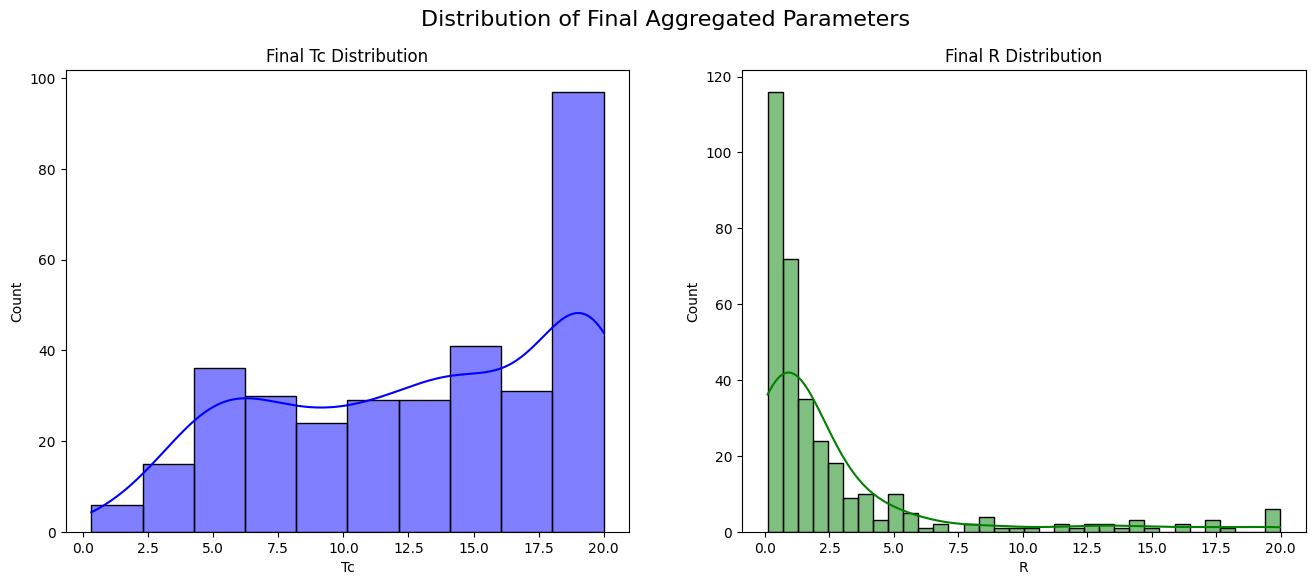


Analysis complete. The 'df_master' DataFrame is ready for machine learning.

Final master dataset saved to: /Users/alan/Data Science Projects/ML-ModClark-IUH-Model/data/gold/tabular/machine_learning/df_master.csv


In [25]:
# Identify valid watersheds that pass the CV check
valid_overall_ws = cv_overall[
    (cv_overall['cv_tc'] < CV_THRESHOLD_TC) & (cv_overall['cv_r'] < CV_THRESHOLD_R)
]['ws_id']

# Aggregate the valid watersheds to get the final mean values
overall_aggregated = df_overall_candidates[df_overall_candidates['ws_id'].isin(valid_overall_ws)].groupby('ws_id').agg(
    Tc=('Tc', 'mean'),
    R=('R', 'mean')
).reset_index()

# To add land use features, we'll use the MOST RECENT land cover data for each watershed
latest_lc = df_lc_yearly.loc[df_lc_yearly.groupby('ws_id')['year'].idxmax()]
df_final_overall = pd.merge(overall_aggregated, latest_lc, on='ws_id', how='left')


print(f"Original watersheds in this group: {len(ws_agg_overall)}")
print(f"Watersheds after CV filter: {len(df_final_overall)}")
print(f"Watersheds discarded due to high CV: {len(ws_agg_overall) - len(df_final_overall)}\n")



#-------------------------------------------------------------------------------
## Step 4: Combine into Final Master DataFrame
#-------------------------------------------------------------------------------
print("--- Creating Final Master Dataset ---")

# Concatenate the two final dataframes
df_master = pd.concat([df_final_yearly, df_final_overall], ignore_index=True)
df_master = df_master.drop(columns='pct_developed')

# Select only the relevant columns from land cover for the final master dataset
land_cover_categories_columns = [
    'pct_developed', 'pct_forest', 'pct_agriculture',
    'pct_grass_scrub', 'pct_wetlands', 'pct_water', 'pct_barren'
]
df_land_cover_selected_columns = df_land_cover[['ws_id', 'year'] + land_cover_categories_columns]
df_master = pd.merge(df_master, df_land_cover_selected_columns, on=['ws_id', 'year'], how='left')

# Load geocharacteristics for the final master dataset
geo_path = PROJECT_ROOT / "data/gold/tabular/geomorphological_characteristics.csv"
geo_df = pd.read_csv(geo_path, dtype={'Station ID': str})
geo_df = geo_df.rename(columns={'Station ID': 'ws_id'})
df_master = pd.merge(df_master, geo_df, on='ws_id', how='left')

print("Final Master DataFrame Info:")
df_master.info()
print("\nNumber of final datapoints:", df_master.shape[0])
print("Number of unique watersheds:", df_master['ws_id'].nunique())
print("\nFinal Master DataFrame Description:")
print(df_master.describe())

# Distribution of final Storm Events NSE
final_selected_events = df_master.drop_duplicates(subset='ws_id').merge(df_filtered,  how='left', on='ws_id')
print("\nDistribution of final Storm Events NSE:")
print(final_selected_events['nse_category'].value_counts())
print("\n")

# --- Visualization of Final Dataset ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Distribution of Final Aggregated Parameters', fontsize=16)

sns.histplot(df_master['Tc'], kde=True, ax=axes[0], color='blue')
axes[0].set_title('Final Tc Distribution')

sns.histplot(df_master['R'], kde=True, ax=axes[1], color='green')
axes[1].set_title('Final R Distribution')

plt.show()

# Save the final master dataset
out_path = PROJECT_ROOT / "data/gold/tabular//machine_learning/df_master.csv"
df_master.columns = df_master.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('[^a-zA-Z0-9_]', '', regex=True)

out_path.parent.mkdir(parents=True, exist_ok=True)
df_master.to_csv(out_path, index=False)
print("\nAnalysis complete. The 'df_master' DataFrame is ready for machine learning.")
print(f"\nFinal master dataset saved to: {out_path}")
